# `sbi` Package Tutorial

This notebook demonstrates all functionality in the `sbi` package:
- **Models**: `DeepSets`, `GRUEstimator` (with subclassing via `alter_inputs`/`alter_outputs`)
- **Training**: `train()` — unified loop, auto-detects uniform vs importance sampling
- **Evaluation**: `evaluate()`, `compare_models()`, `binned_mse()`, `heatmap_2d()`
- **Proposals**: `BetaProposal` for importance sampling
- **Simulation**: `simulate_ar1_batch` for AR(1) time series

In [1]:
import numpy as np
import torch
from sbi import (DeepSets, GRUEstimator, train, evaluate,
                 compare_models, binned_mse, heatmap_2d,
                 BetaProposal, simulate_ar1_batch)

## Example 1: Normal distribution with unknown mean and variance

$$\mu \sim \mathcal{N}(0, 1), \quad \sigma \sim \text{Uniform}(0, 5)$$

Given $n=64$ observations $x_i \sim \mathcal{N}(\mu, \sigma^2)$, estimate $(\mu, \sigma)$.

In [ ]:
# Problem setup
mu0, sigma0, A, n = 0, 1, 5, 64

def sample_normal(batch_size):
    mu = np.random.normal(mu0, sigma0, size=batch_size)
    sigma = np.random.uniform(0, A, size=batch_size)
    x = np.array([np.random.normal(mu[i], sigma[i], size=n) for i in range(batch_size)])
    return np.stack([mu, sigma], axis=1), x

# Subclass DeepSets: add log-variance feature, sigmoid output for sigma
class DeepSetsNormal(DeepSets):
    def __init__(self):
        super().__init__(input_dim=1, output_dim=2)

    # def alter_inputs(self, x):
    #     var = torch.var(x, dim=1, keepdim=True)
    #     log_var = torch.log(var).expand_as(x)
    #     return torch.stack([x, log_var], dim=-1)

    def alter_outputs(self, x):
        mu = x[:, 0]
        sigma = torch.sigmoid(x[:, 1]) * A
        return torch.stack([mu, sigma], dim=1)

Training — device: cuda, IS: False, epochs: 50
  Epoch 6/50, Test Loss: 0.0923
  Epoch 12/50, Test Loss: 0.0866
  Epoch 18/50, Test Loss: 0.0826
  Epoch 24/50, Test Loss: 0.0876
  Epoch 30/50, Test Loss: 0.0883
  Epoch 36/50, Test Loss: 0.0830
  Epoch 42/50, Test Loss: 0.0819
  Epoch 48/50, Test Loss: 0.0823


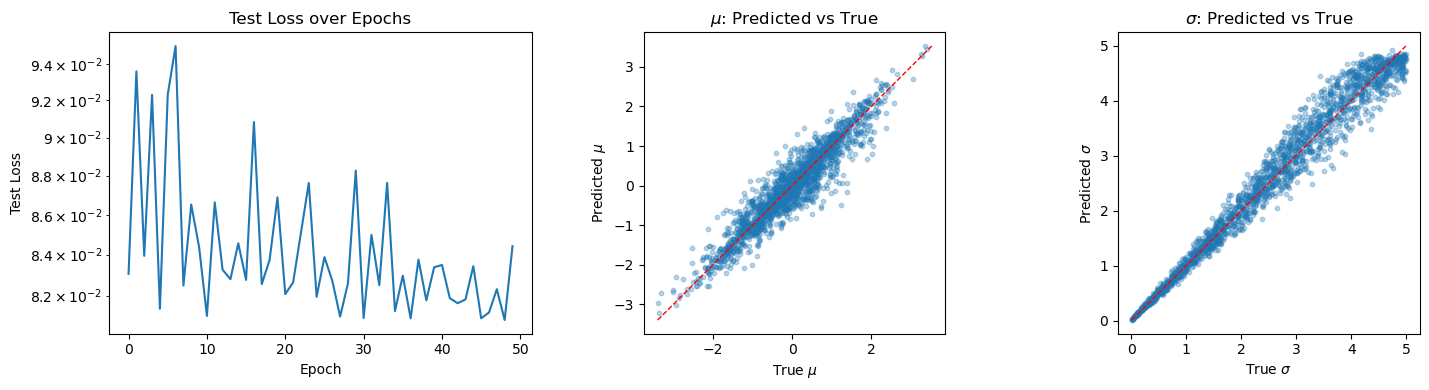

  MSE($\mu$): 0.1156
  MSE($\sigma$): 0.0593
  Total MSE: 0.1749


In [3]:
# Train and evaluate — just 2 lines
model_normal = DeepSetsNormal()
model_normal, history_normal = train(model_normal, sample_normal, n_epochs=50)
evaluate(model_normal, sample_normal, history_normal, [r'$\mu$', r'$\sigma$'])

## Adding Importance Sampling

The baseline struggles with small $\sigma$ because uniform sampling rarely produces them. We use a `BetaProposal` to oversample these regions. The `train()` function auto-detects IS when `sample_fn` returns 3 values `(theta, x, weights)`.

In [4]:
from scipy import stats

def sample_normal_is(batch_size, alpha_sigma=0.5):
    """IS proposal: oversample small sigma with Beta(alpha, 1)."""
    mu = np.random.normal(mu0, sigma0, size=batch_size)
    sigma_tilde = np.random.beta(alpha_sigma, 1.0, size=batch_size)
    sigma = A * sigma_tilde
    x = np.array([np.random.normal(mu[i], sigma[i], size=n) for i in range(batch_size)])
    q = stats.beta.pdf(sigma_tilde, alpha_sigma, 1.0)
    weights = 1.0 / q
    return np.stack([mu, sigma], axis=1), x, weights

# Train IS model — train() auto-detects the 3-tuple return
model_is = DeepSetsNormal()
model_is, history_is = train(model_is, sample_normal_is, n_epochs=50, seed=0)

Training — device: cuda, IS: True, epochs: 50
  Epoch 6/50, Test Loss: 0.0566
  Epoch 12/50, Test Loss: 0.0526
  Epoch 18/50, Test Loss: 0.0549
  Epoch 24/50, Test Loss: 0.0520
  Epoch 30/50, Test Loss: 0.0532
  Epoch 36/50, Test Loss: 0.0539
  Epoch 42/50, Test Loss: 0.0536
  Epoch 48/50, Test Loss: 0.0523


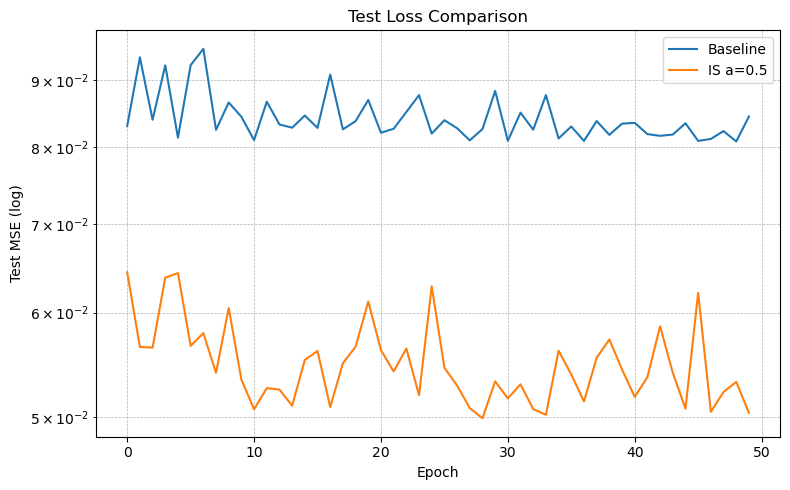

Model                       MSE($\mu$) MSE($\sigma$)      Total
-----------------------------------------------------------
Baseline                        0.1156       0.0567     0.1724
IS a=0.5                        0.1121       0.0575     0.1696


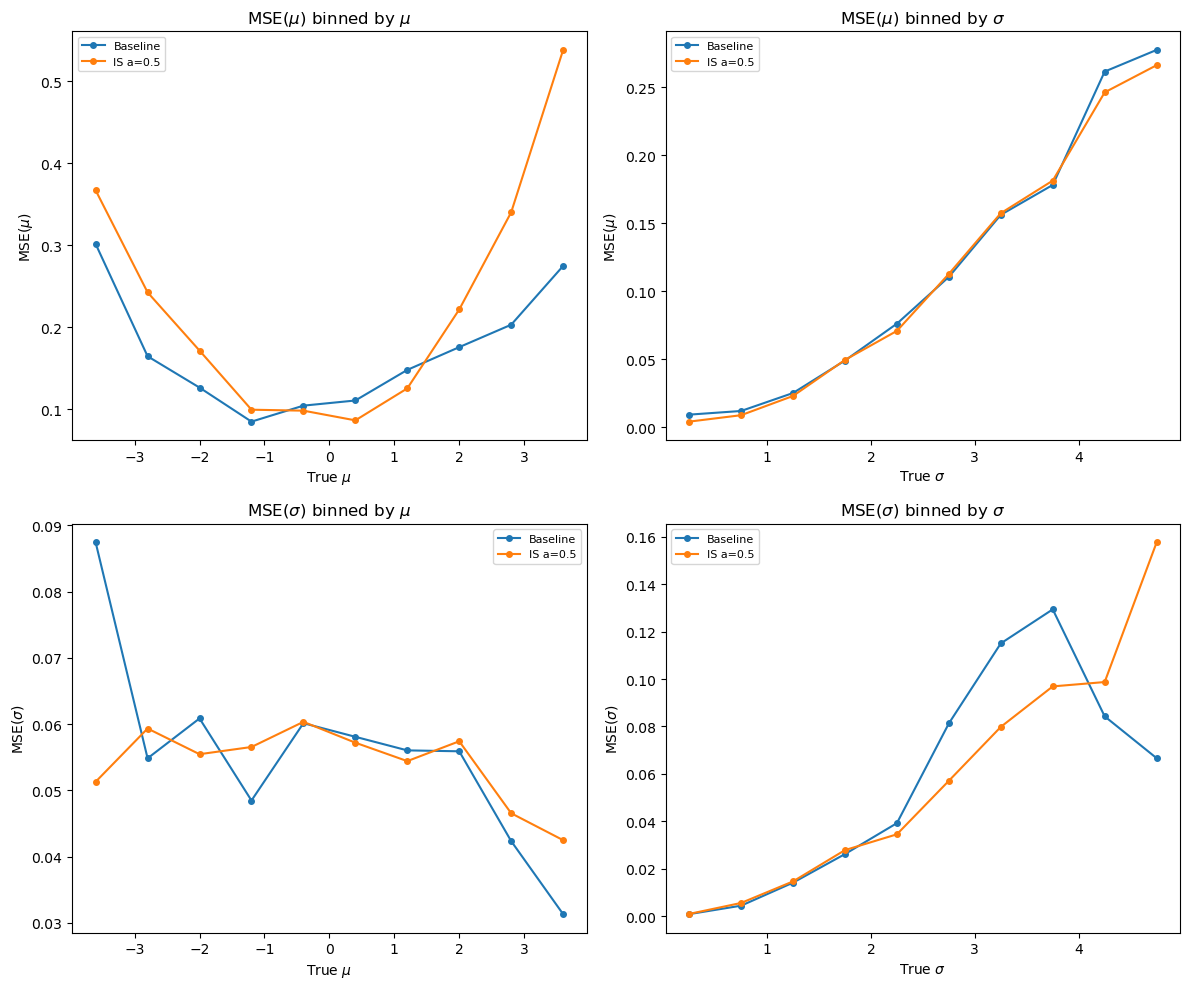

In [5]:
# Compare models side by side
test_data = sample_normal(4000)
test_set = (torch.tensor(test_data[0], dtype=torch.float32),
            torch.tensor(test_data[1], dtype=torch.float32))

compare_models(
    models={'Baseline': model_normal, 'IS a=0.5': model_is},
    histories={'Baseline': history_normal, 'IS a=0.5': history_is},
    test_set=test_set,
    param_names=[r'$\mu$', r'$\sigma$'],
    param_ranges=[(-4, 4), (0, A)]
)

## Example 2: AR(1) Time Series

$$X_t = \rho X_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma^2)$$

Priors: $\rho \sim \text{Uniform}(-1, 1)$, $\sigma \sim \text{Uniform}(0, 5)$. We use `GRUEstimator` + `simulate_ar1_batch`.

Training — device: cuda, IS: False, epochs: 50
  Epoch 6/50, Test Loss: 0.0527
  Epoch 12/50, Test Loss: 0.0461
  Epoch 18/50, Test Loss: 0.0445
  Epoch 24/50, Test Loss: 0.0414
  Epoch 30/50, Test Loss: 0.0440
  Epoch 36/50, Test Loss: 0.0425
  Epoch 42/50, Test Loss: 0.0402
  Epoch 48/50, Test Loss: 0.0400


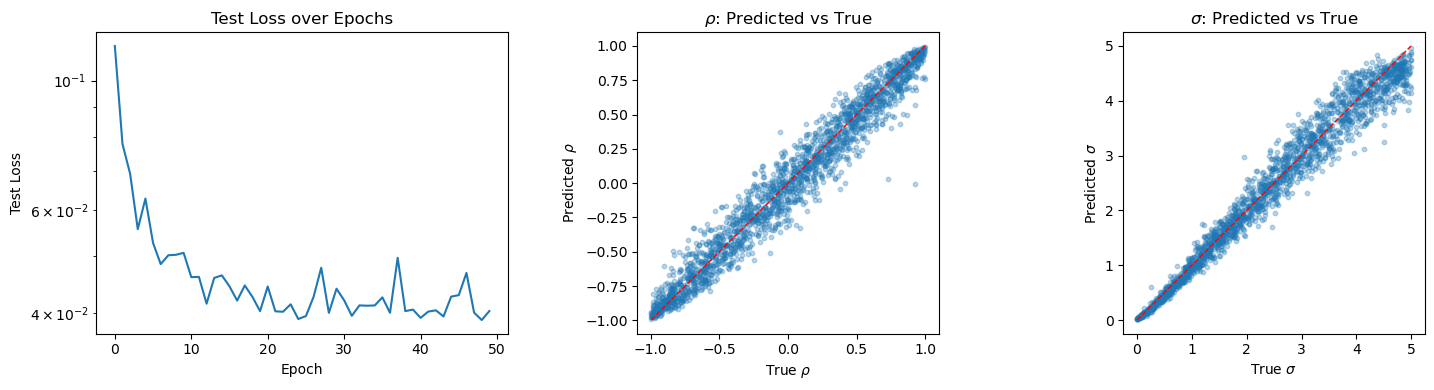

  MSE($\rho$): 0.0138
  MSE($\sigma$): 0.0627
  Total MSE: 0.0764


In [6]:
A_ar1 = 5.0
T = 64

class AR1Estimator(GRUEstimator):
    def alter_outputs(self, x):
        rho = torch.tanh(x[:, 0])
        sigma = torch.exp(x[:, 1])
        return torch.stack([rho, sigma], dim=1)

def sample_ar1(batch_size):
    rho = torch.empty(batch_size).uniform_(-1, 1)
    sigma = torch.empty(batch_size).uniform_(0, A_ar1)
    x = simulate_ar1_batch(rho, sigma, T)
    return torch.stack([rho, sigma], dim=1), x

model_ar1 = AR1Estimator()
model_ar1, history_ar1 = train(model_ar1, sample_ar1, n_epochs=50, n_batches=128, lr=2e-3)
evaluate(model_ar1, sample_ar1, history_ar1, [r'$\rho$', r'$\sigma$'])

## Advanced Evaluation

`binned_mse()` and `heatmap_2d()` provide detailed spatial analysis of model performance.

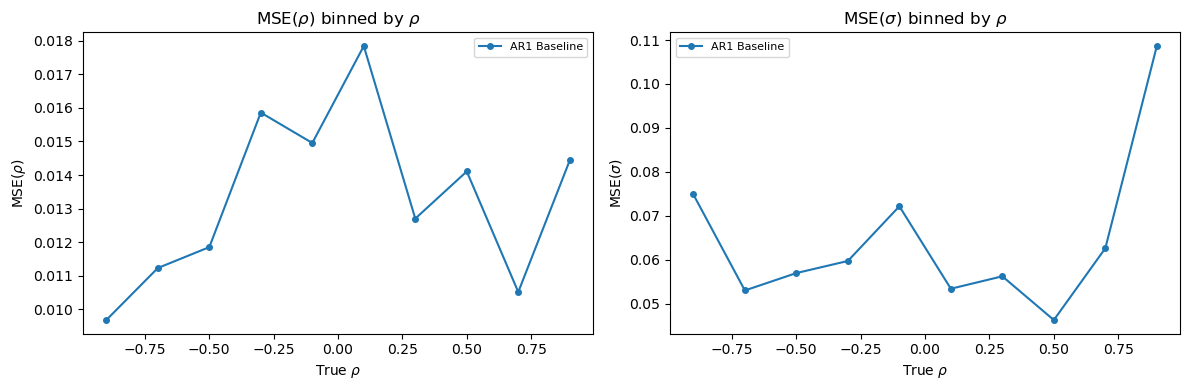

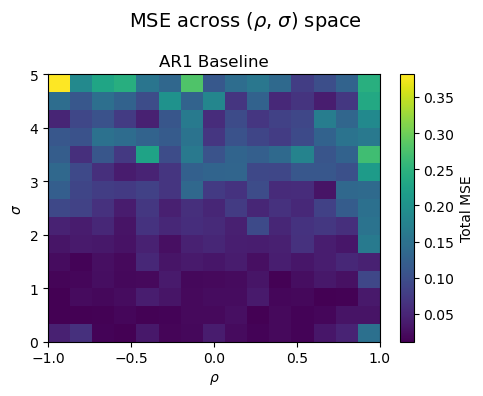

In [7]:
# Generate shared test set and predictions
test_ar1 = sample_ar1(4000)
device = next(model_ar1.parameters()).device
theta_true = test_ar1[0].numpy()

model_ar1.eval()
with torch.no_grad():
    pred_np = model_ar1(test_ar1[1].to(device)).cpu().numpy()

predictions = {'AR1 Baseline': pred_np}

# Binned MSE — bin by rho (index 0)
binned_mse(theta_true, predictions, [r'$\rho$', r'$\sigma$'], bin_by=0)

# 2D heatmap
heatmap_2d(theta_true, predictions, [r'$\rho$', r'$\sigma$'],
           param_ranges=[(-1, 1), (0, A_ar1)])